In [3]:
import numpy as np
import pandas as pd

Accuracy: 0.8800


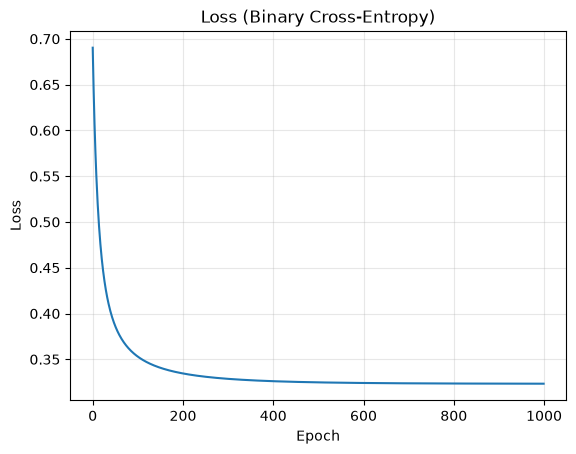

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Создаём класс Perceptron
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        # Производная сигмоиды = z * (1 - z)
        return z * (1 - z)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        for epoch in range(self.n_epochs):
            # Прямой проход (forward pass)
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            # Функция потерь (MSE для регрессии, но мы используем бинарную кросс-энтропию)
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.loss_history.append(loss)

            # Обратный проход (backpropagation)
            # Градиент по выходу
            d_loss = y_pred - y
            # Градиент по весам и смещению
            d_weights = (1 / n_samples) * np.dot(X.T, d_loss)
            d_bias = (1 / n_samples) * np.sum(d_loss)

            # Обновление весов
            self.weights -= self.lr * d_weights
            self.bias -= self.lr * d_bias

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(z)
        return (y_pred >= 0.5).astype(int)

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)


# 2. Тестируем на синтетических данных
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

perceptron = Perceptron(learning_rate=0.1, n_epochs=1000)
perceptron.fit(X_train, y_train)

# 3. Оценка
y_pred = perceptron.predict(X_test)
print(f"Accuracy: {np.mean(y_pred == y_test):.4f}")

# 4. График потерь
plt.plot(perceptron.loss_history)
plt.title('Loss (Binary Cross-Entropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
class NeuralNetwork:
    def __init__(self,input_size, hidden_size, output_size, learning_rate=0.001, n_epochs=1000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size 
        self.learning_rate = learning_rate

        self.w1 = np.random.randn(self.input_size,self.hidden_size) * 0.01
        self.b1 = np.zeros((1,self.hidden_size))

        self.w2 = np.random.randn(self.hidden_size,self.output_size) * 0.01
        self.b2 = np.zeros((1,self.output_size))

        self.loss_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self,X):
        self.z1 = X@self.w1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1@self.w2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self,X,y):
        n = X.shape[0]

        # Градиент на выходе (производная бинарной кросс-энтропии + сигмоиды)
        d_loss = self.a2 - y

        # Градиенты для выходного слоя
        dw2 = (1/n) * self.a1.T @ d_loss  # Изменено: self.a1.T @ d_loss
        db2 = (1/n) * np.sum(d_loss, axis=0, keepdims=True)

        # Градиент для скрытого слоя (обратное распространение)
        da1 = d_loss @ self.w2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dw1 = (1/n) * X.T @ dz1
        db1 = (1/n) * np.sum(dz1, axis=0, keepdims=True)

        self.w1 -= self.learning_rate * dw1
        self.b1 -= self.learning_rate * db1
        self.w2 -= self.learning_rate * dw2
        self.b2 -= self.learning_rate * db2

    def fit(self,X,y,epochs = 1000,verbose = False):
        for epoch in range(epochs):
            # Прямой проход
            y_pred = self.forward(X)

            # Функция потерь (бинарная кросс-энтропия)
            loss =  -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.loss_history.append(loss)

            # Обратный проход и обновление весов
            self.backward(X, y)

            if verbose and epochs % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")


    def predict(self,X):
        predict = self.forward(X)
        return (predict>=0.5).astype(int)

    def predict_proba(self,X):
        return self.forward(X)

    

Epoch 0: Loss = 0.6930
Epoch 100: Loss = 0.4724
Epoch 200: Loss = 0.2620
Epoch 300: Loss = 0.2297
Epoch 400: Loss = 0.2159
Epoch 500: Loss = 0.2085
Epoch 600: Loss = 0.2043
Epoch 700: Loss = 0.2011
Epoch 800: Loss = 0.1988
Epoch 900: Loss = 0.1967
Accuracy: 0.4990


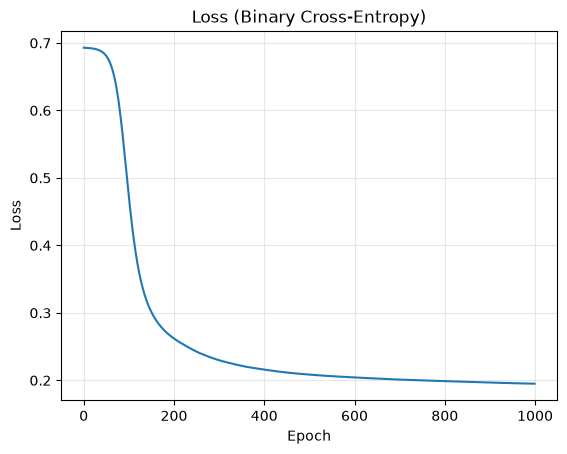

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001, n_epochs=1000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size 
        self.learning_rate = learning_rate

        self.w1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        self.w2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

        self.loss_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Убеждаемся, что X имеет правильную форму
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        self.z1 = X @ self.w1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.w2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Градиент на выходе (производная бинарной кросс-энтропии + сигмоиды)
        d_loss = self.a2 - y

        # Градиенты для выходного слоя
        dw2 = (1/n) * self.a1.T @ d_loss
        db2 = (1/n) * np.sum(d_loss, axis=0, keepdims=True)

        # Градиент для скрытого слоя (обратное распространение)
        da1 = d_loss @ self.w2.T
        dz1 = da1 * self.relu_derivative(self.z1)

        dw1 = (1/n) * X.T @ dz1
        db1 = (1/n) * np.sum(dz1, axis=0, keepdims=True)

        self.w1 -= self.learning_rate * dw1
        self.b1 -= self.learning_rate * db1
        self.w2 -= self.learning_rate * dw2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y, epochs=1000, verbose=False):
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        for epoch in range(epochs):
            # Прямой проход
            y_pred = self.forward(X)

            # Функция потерь (бинарная кросс-энтропия)
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.loss_history.append(loss)

            # Обратный проход и обновление весов
            self.backward(X, y)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        predict = self.forward(X)
        return (predict >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward(X)

# Создание данных
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
nn = NeuralNetwork(input_size=2, hidden_size=10, output_size=1, learning_rate=0.1, n_epochs=1000)
nn.fit(X_train, y_train, verbose=True)

# Оценка
y_pred = nn.predict(X_test)
print(f"Accuracy: {np.mean(y_pred == y_test):.4f}")

# График потерь
plt.plot(nn.loss_history)
plt.title('Loss (Binary Cross-Entropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
class NeuralNetwork_Dropout:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001, n_epochs=1000,dropout_rate=0.5):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size 
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.dropout_rate = dropout_rate

        self.w1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        self.w2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

        self.mask1 = None

        self.loss_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X,training = True):
        # Убеждаемся, что X имеет правильную форму
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        self.z1 = X @ self.w1 + self.b1
        self.a1 = self.relu(self.z1)

        if training:
            self.mask1 = (np.random.rand(*self.a1.shape) > self.dropout_rate).astype(float)
            self.a1 = self.a1 * self.mask1
            self.a1 = self.a1 / (1-self.dropout_rate)

        self.z2 = self.a1 @ self.w2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Градиент на выходе (производная бинарной кросс-энтропии + сигмоиды)
        d_loss = self.a2 - y

        # Градиенты для выходного слоя
        dw2 = (1/n) * self.a1.T @ d_loss
        db2 = (1/n) * np.sum(d_loss, axis=0, keepdims=True)

        # Градиент для скрытого слоя (обратное распространение)
        da1 = d_loss @ self.w2.T
        da1 = da1 * self.mask1
        da1 = da1 / (1-self.dropout_rate)
        dz1 = da1 * self.relu_derivative(self.z1)

        dw1 = (1/n) * X.T @ dz1
        db1 = (1/n) * np.sum(dz1, axis=0, keepdims=True)

        self.w1 -= self.learning_rate * dw1
        self.b1 -= self.learning_rate * db1
        self.w2 -= self.learning_rate * dw2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y, epochs=None, verbose=False):
        if epochs is None:
            epochs = self.n_epochs
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        
        for epoch in range(self.n_epochs):
            # Прямой проход
            y_pred = self.forward(X,training=True)

            # Функция потерь (бинарная кросс-энтропия)
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.loss_history.append(loss)

            # Обратный проход и обновление весов
            self.backward(X, y)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        predict = self.forward(X,training=False)
        return (predict >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward(X,training=False)


In [8]:
class NeuralNetwork_BN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001, n_epochs=1000,dropout_rate=0.5,use_bn=True,momentum = 0.9, eps = 1e-8,batch_size=32):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size 
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.dropout_rate = dropout_rate
        self.use_bn = use_bn
        self.momentum = momentum
        self.eps = eps
        self.batch_size = batch_size
        
        self.w1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        self.w2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

        self.mask1 = None

        self.gamma1 = np.ones((1,hidden_size))
        self.beta1 = np.zeros((1,hidden_size))

        self.running_mean1 = np.zeros((1, hidden_size))
        self.running_var1 = np.ones((1, hidden_size))

        self.loss_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def batch_norm(self,X,gamma, beta, running_mean, running_var, training):
        if training:
            mean = np.mean(X,axis = 0)
            var = np.var(X,axis = 0)

            running_mean = self.momentum * running_mean + (1 - self.momentum) * mean
            running_var = self.momentum * running_var + (1 - self.momentum) * var
        else:
            mean = running_mean
            var = running_var

        X_norm = (X-mean)/ np.sqrt(var + self.eps)
        out = gamma * X_norm + beta
    
        # Сохраняем для backward
        self.x_norm = X_norm
        self.mean = mean
        self.var = var
        
        return out


    def forward(self, X,training = True):
        # Убеждаемся, что X имеет правильную форму
        if X.ndim == 1:
            X = X.reshape(1, -1)
        
        self.z1 = X @ self.w1 + self.b1
        self.z1 = self.batch_norm(self.z1, self.gamma1, self.beta1, self.running_mean1, self.running_var1, training)
        self.a1 = self.relu(self.z1)

        if training:
            self.mask1 = (np.random.rand(*self.a1.shape) > self.dropout_rate).astype(float)
            self.a1 = self.a1 * self.mask1
            self.a1 = self.a1 / (1-self.dropout_rate)

        self.z2 = self.a1 @ self.w2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        n = X.shape[0]
        
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Градиент на выходе (производная бинарной кросс-энтропии + сигмоиды)
        d_loss = self.a2 - y

        # Градиенты для выходного слоя
        dw2 = (1/n) * self.a1.T @ d_loss
        db2 = (1/n) * np.sum(d_loss, axis=0, keepdims=True)

        # Градиент для скрытого слоя (обратное распространение)
        da1 = d_loss @ self.w2.T
        da1 = da1 * self.mask1
        da1 = da1 / (1-self.dropout_rate)
        
        n = X.shape[0]
        x_norm = self.x_norm
        mean = self.mean
        var = self.var
        
        # Градиент по gamma и beta
        d_gamma = np.sum(da1 * x_norm, axis=0, keepdims=True)
        d_beta = np.sum(da1, axis=0, keepdims=True)

        # Градиент по входу X (обратный проход BN)
        d_x = (1/n) * self.gamma1 * (1 / np.sqrt(var + self.eps)) * (n * da1 - d_beta - x_norm * d_gamma)

        # Теперь продолжаем обратное распространение, используя d_x вместо da1
        dz1 = d_x * self.relu_derivative(self.z1)

        dw1 = (1/n) * X.T @ dz1
        db1 = (1/n) * np.sum(dz1, axis=0, keepdims=True)

        self.w1 -= self.learning_rate * dw1
        self.b1 -= self.learning_rate * db1
        self.w2 -= self.learning_rate * dw2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y, epochs=None, verbose=False):
        if epochs is None:
            epochs = self.n_epochs
        # Убеждаемся, что y имеет правильную форму
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        n_samples = X.shape[0]
        
        for epoch in range(self.n_epochs):
            # Прямой проход
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            n_batches = 0

            # Проходим по батчам
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                y_pred = self.forward(X_batch,training=True)

                # Функция потерь (бинарная кросс-энтропия)
                loss = -np.mean(y_batch * np.log(y_pred + 1e-8) + (1 - y_batch) * np.log(1 - y_pred + 1e-8))
                self.loss_history.append(loss)

                epoch_loss += loss
                n_batches += 1

                # Обратный проход и обновление весов
                self.backward(X_batch, y_batch)

            # Усредняем loss по эпохе
            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")
    def predict(self, X):
        predict = self.forward(X,training=False)
        return (predict >= 0.5).astype(int)

    def predict_proba(self, X):
        return self.forward(X,training=False)


Epoch 0: Loss = 0.6827
Epoch 100: Loss = 0.3540
Epoch 200: Loss = 0.3317
Epoch 300: Loss = 0.3229
Epoch 400: Loss = 0.3526
Epoch 500: Loss = 0.2911
Epoch 600: Loss = 0.3036
Epoch 700: Loss = 0.2950
Epoch 800: Loss = 0.3119
Epoch 900: Loss = 0.3078
Epoch 1000: Loss = 0.3118
Epoch 1100: Loss = 0.2946
Epoch 1200: Loss = 0.3779
Epoch 1300: Loss = 0.2856
Epoch 1400: Loss = 0.2980
Accuracy: 0.4980


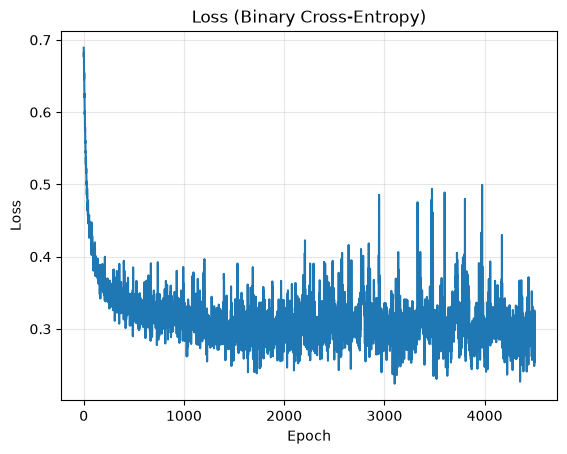

In [9]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
nn = NeuralNetwork_BN(
    input_size=2, 
    hidden_size=5, 
    output_size=1, 
    learning_rate=0.1, 
    n_epochs=1500,
    dropout_rate=0.0,   # Отключаем Dropout
    use_bn=True,
    batch_size=256
)

nn.fit(X_train, y_train, verbose=True)

# Оценка
y_pred = nn.predict(X_test)
print(f"Accuracy: {np.mean(y_pred == y_test):.4f}")

# График потерь
plt.plot(nn.loss_history)
plt.title('Loss (Binary Cross-Entropy)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# 1. Данные
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 2. Масштабирование (важно для нейросетей)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# 3. Преобразуем в PyTorch тензоры
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

In [14]:
# 4. Определяем модель
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [15]:
# 5. Инициализация модели, функции потерь, оптимизатора
model = SimpleNN(input_size=2, hidden_size=10, output_size=1)
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [16]:
# 6. Обучение
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # Прямой проход
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss_history.append(loss.item())

    # Обратный проход (автоматически!)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 0.7877
Epoch 100: Loss = 0.2276
Epoch 200: Loss = 0.1915
Epoch 300: Loss = 0.1405
Epoch 400: Loss = 0.1585
Epoch 500: Loss = 0.1284
Epoch 600: Loss = 0.1433
Epoch 700: Loss = 0.1588
Epoch 800: Loss = 0.1545
Epoch 900: Loss = 0.1331


Accuracy: 0.9700


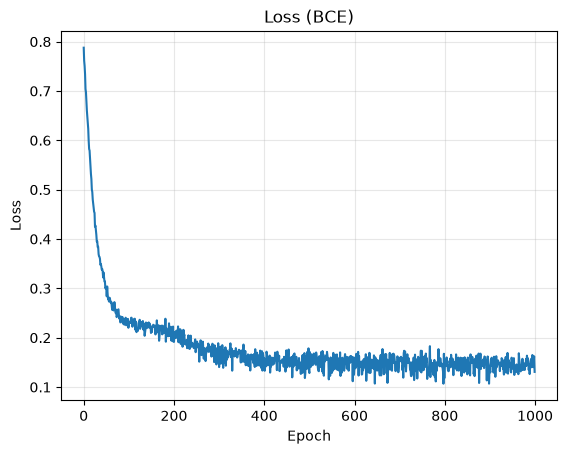

In [17]:

# 7. Оценка
with torch.no_grad():  # отключаем градиенты (экономия памяти)
    y_pred_test = model(X_test)
    y_pred_class = (y_pred_test >= 0.5).float()
    accuracy = (y_pred_class == y_test).float().mean().item()

print(f"Accuracy: {accuracy:.4f}")

# 8. График потерь
plt.plot(loss_history)
plt.title('Loss (BCE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# 1. Создание тензоров
a = torch.tensor([1, 2, 3])
b = torch.zeros((2, 3))
c = torch.randn((3, 3))  # нормальное распределение
a

tensor([1, 2, 3])

In [19]:
b

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [20]:
c

tensor([[-0.1938,  1.4919,  0.9942],
        [ 0.5026, -1.1365,  0.2117],
        [ 1.0689,  0.8345, -0.0795]])

In [21]:
# 2. Операции
d = a + 10
e = torch.matmul(c, c.T)  # матричное умножение
d

tensor([11, 12, 13])

In [22]:
e

tensor([[ 3.2516, -1.5825,  0.9588],
        [-1.5825,  1.5891, -0.4280],
        [ 0.9588, -0.4280,  1.8452]])

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
a_gpu = a.to(device)
print(f"Тензор на {device}: {a_gpu}")

Тензор на cpu: tensor([1, 2, 3])


In [24]:
x = torch.tensor(2.0, requires_grad=True)  # включили отслеживание градиента

y = x**2 + 3*x + 1
y.backward()  # автоматическое дифференцирование

print(f"Градиент dy/dx при x=2: {x.grad.item()}")  # должно быть 7 (2x+3 = 4+3)

Градиент dy/dx при x=2: 7.0


In [25]:
import torch.nn as nn
import torch.optim as optim

class MyModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [26]:
# 1. Данные
X = torch.randn(100, 5)
y = torch.randint(0, 2, (100, 1)).float()


In [27]:
# 2. Модель, loss, оптимизатор
model = MyModel(5, 10, 1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [28]:
# 3. Цикл обучения
for epoch in range(2000):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.6941
Epoch 500: Loss = 0.1741
Epoch 1000: Loss = 0.0762
Epoch 1500: Loss = 0.0437


In [29]:
# Учимся с Dropout
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 10)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.dropout(x)  # на train — выключает нейроны, на eval — не выключает
        x = self.fc2(x)
        return self.sigmoid(x)

model = ModelWithDropout()

In [30]:
# Обучение
model.train()
y_pred_train = model(X)  # Dropout активен

# Инференс
model.eval()
with torch.no_grad():
    y_pred_test = model(X)  # Dropout выключен

In [31]:
from sklearn.datasets import make_moons

# 1. Данные
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc =StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Преобразование в тензоры PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.batchnorm = nn.BatchNorm1d(8)
        self.dropout = nn.Dropout(0.2)
        self.fc3 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Первый скрытый слой
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)  # Dropout после активации

        # Второй скрытый слой
        x = self.fc2(x)
        x = self.batchnorm(x)  # BN перед активацией (или после — можно и так, но чаще перед)
        x = self.relu(x)
        x = self.dropout(x)

        # Выходной слой
        x = self.fc3(x)
        return self.sigmoid(x)


# 2. Модель, loss, оптимизатор
model = MyModel()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history = []

# 3. Цикл обучения
for epoch in range(500):
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss_history.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.6720
Epoch 100: Loss = 0.1186
Epoch 200: Loss = 0.1249
Epoch 300: Loss = 0.1124
Epoch 400: Loss = 0.1078


In [32]:
# 5. Оценка
with torch.no_grad():
    y_pred_test = model(X_test_t)
    y_pred_class = (y_pred_test >= 0.5).float()
    accuracy = (y_pred_class == y_test_t).float().mean().item()

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9550


In [39]:
from sklearn.model_selection import train_test_split

# 1. Сначала раздели на train и test (ты уже это сделал)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Теперь раздели X_train на train и validation (10% от train)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [40]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

In [41]:
patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None
train_loss_history = []
val_loss_history = []
epochs = 5000

for epoch in range(epochs):
    # --- ОБУЧЕНИЕ ---
    model.train()
    y_pred_train = model(X_train_t)
    train_loss = criterion(y_pred_train, y_train_t)
    train_loss_history.append(train_loss.item())

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # --- ВАЛИДАЦИЯ ---
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_t)
        val_loss = criterion(y_pred_val, y_val_t)
        val_loss_history.append(val_loss.item())

    # --- EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()  # сохраняем лучшую модель
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

Early stopping triggered at epoch 147


In [42]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

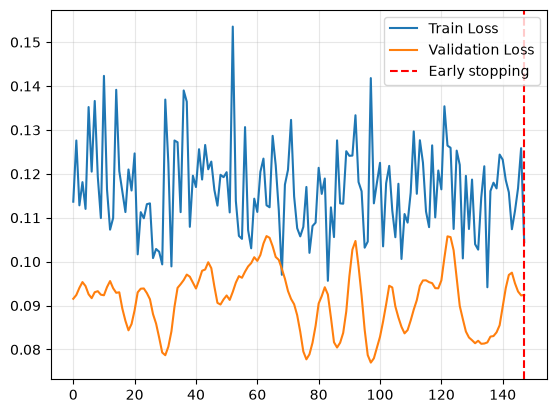

In [43]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.axvline(x=len(train_loss_history)-1, color='red', linestyle='--', label='Early stopping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()